In [28]:
import sys
print(sys.executable)


c:\ecommerce-churn-prediction\ecomvenv\Scripts\python.exe


# E-Commerce Customer Churn — Exploratory Data Analysis
**Day 2** | Project: Churn Prediction | Dataset: E-Commerce Churn (Kaggle)

In [29]:
import sys
print("Python path:", sys.executable)
print("Python version:", sys.version)

Python path: c:\ecommerce-churn-prediction\ecomvenv\Scripts\python.exe
Python version: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


In [30]:
import mlflow
print("mlflow version:", mlflow.__version__)

mlflow version: 3.11.1


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import mlflow

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("mlflow:", mlflow.__version__)
print("\nAll libraries loaded successfully!")

pandas: 2.3.3
numpy: 2.4.4
sklearn: 1.8.0
xgboost: 3.2.0
mlflow: 3.11.1

All libraries loaded successfully!


In [32]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Plot styling — professional look
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

sns.set_palette("husl")

print("All libraries imported successfully!")
print("Working directory:", os.getcwd())

All libraries imported successfully!
Working directory: c:\ecommerce-churn-prediction\notebooks


In [33]:
# Cell 2 — Load data
RAW_DATA_PATH = "../data/raw/E Commerce Dataset.xlsx"

df = pd.read_excel(RAW_DATA_PATH, sheet_name="E Comm")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 5630 rows x 20 columns


In [34]:
# Run this only if Cell 2 throws a sheet error
xl = pd.ExcelFile("../data/raw/E Commerce Dataset.xlsx")
print("Sheet names:", xl.sheet_names)

Sheet names: ['Data Dict', 'E Comm']


In [35]:
# Cell 3 — First look
print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
df.head()

FIRST 5 ROWS


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [36]:
#Last look
print("=" * 50)
print("Last 5 ROWS")
print("=" * 50)
df.tail()

Last 5 ROWS


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169.04


In [37]:
# Cell 4 — Column names and data types
print("COLUMNS AND DATA TYPES")
print("=" * 50)
print(df.dtypes)
print(f"\nTotal columns: {df.shape[1]}")

COLUMNS AND DATA TYPES
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

Total columns: 20


In [38]:
# Cell 5 — Basic statistics
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

STATISTICAL SUMMARY


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [39]:
print(df.shape) # for the size of the dataset
print(df.info())
print(df.columns)

(5630, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberO

In [40]:
# print(df.isnull())
print(df.isnull().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


CHURN DISTRIBUTION
Churn
0    4682
1     948
Name: count, dtype: int64

Churn rate: 16.84%
Retention rate: 83.16%


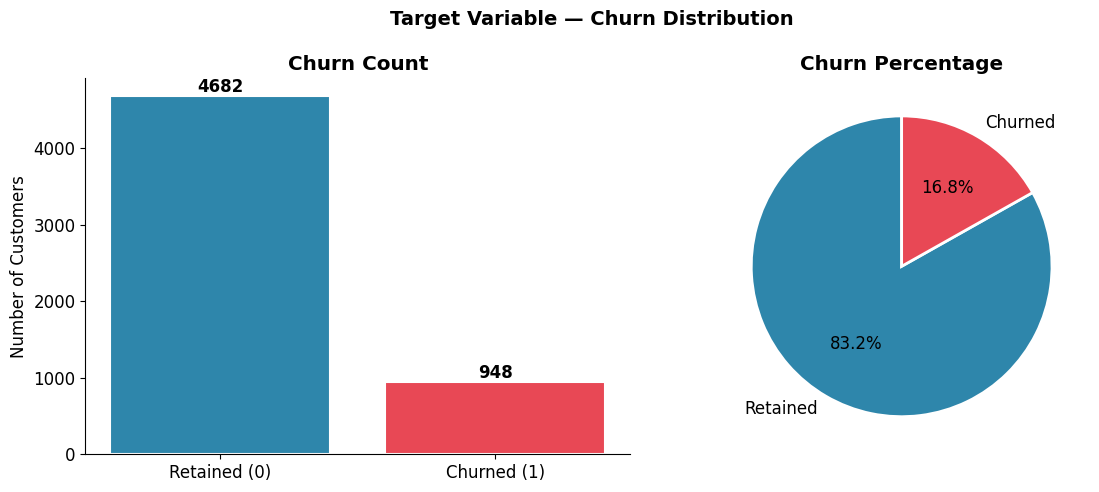

Plot saved to reports/figures/


In [41]:
# Cell 6 — Churn distribution
print("CHURN DISTRIBUTION")
print("=" * 50)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(f"Churn rate: {churn_pct[1]:.2f}%")
print(f"Retention rate: {churn_pct[0]:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Retained (0)', 'Churned (1)'],
            churn_counts.values,
            color=['#2E86AB', '#E84855'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['Retained', 'Churned'],
            autopct='%1.1f%%',
            colors=['#2E86AB', '#E84855'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Percentage', fontweight='bold')

plt.suptitle('Target Variable — Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/figures/")

MISSING VALUE ANALYSIS
                             Missing Count  Missing %
DaySinceLastOrder                      307       5.45
OrderAmountHikeFromlastYear            265       4.71
Tenure                                 264       4.69
OrderCount                             258       4.58
CouponUsed                             256       4.55
HourSpendOnApp                         255       4.53
WarehouseToHome                        251       4.46

Total columns with missing values: 7
Total missing cells: 1856


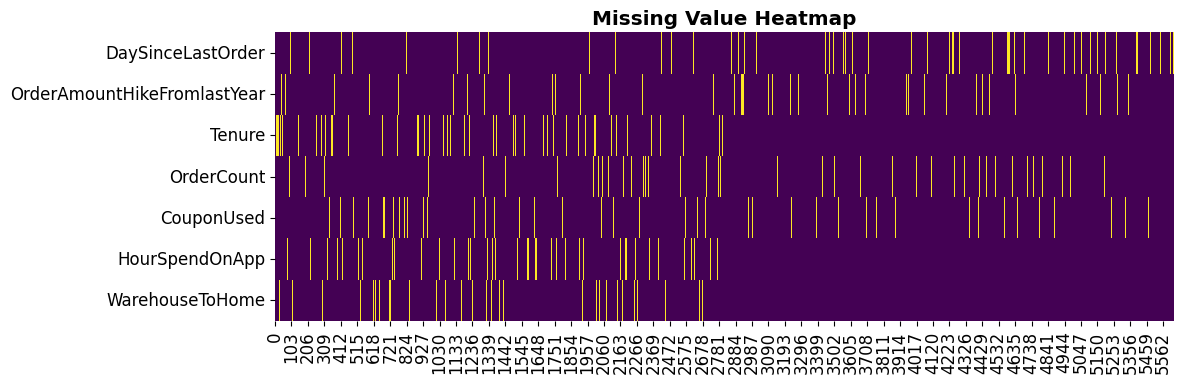

In [42]:
# Cell 7 — Missing values
print("MISSING VALUE ANALYSIS")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)
print(f"\nTotal columns with missing values: {len(missing_df)}")
print(f"Total missing cells: {df.isnull().sum().sum()}")

# Heatmap of missing values
if len(missing_df) > 0:
    plt.figure(figsize=(12, 4))
    missing_data = df[missing_df.index].isnull()
    sns.heatmap(missing_data.T, cbar=False, cmap='viridis', yticklabels=True)
    plt.title('Missing Value Heatmap', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/02_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

Numerical columns: ['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


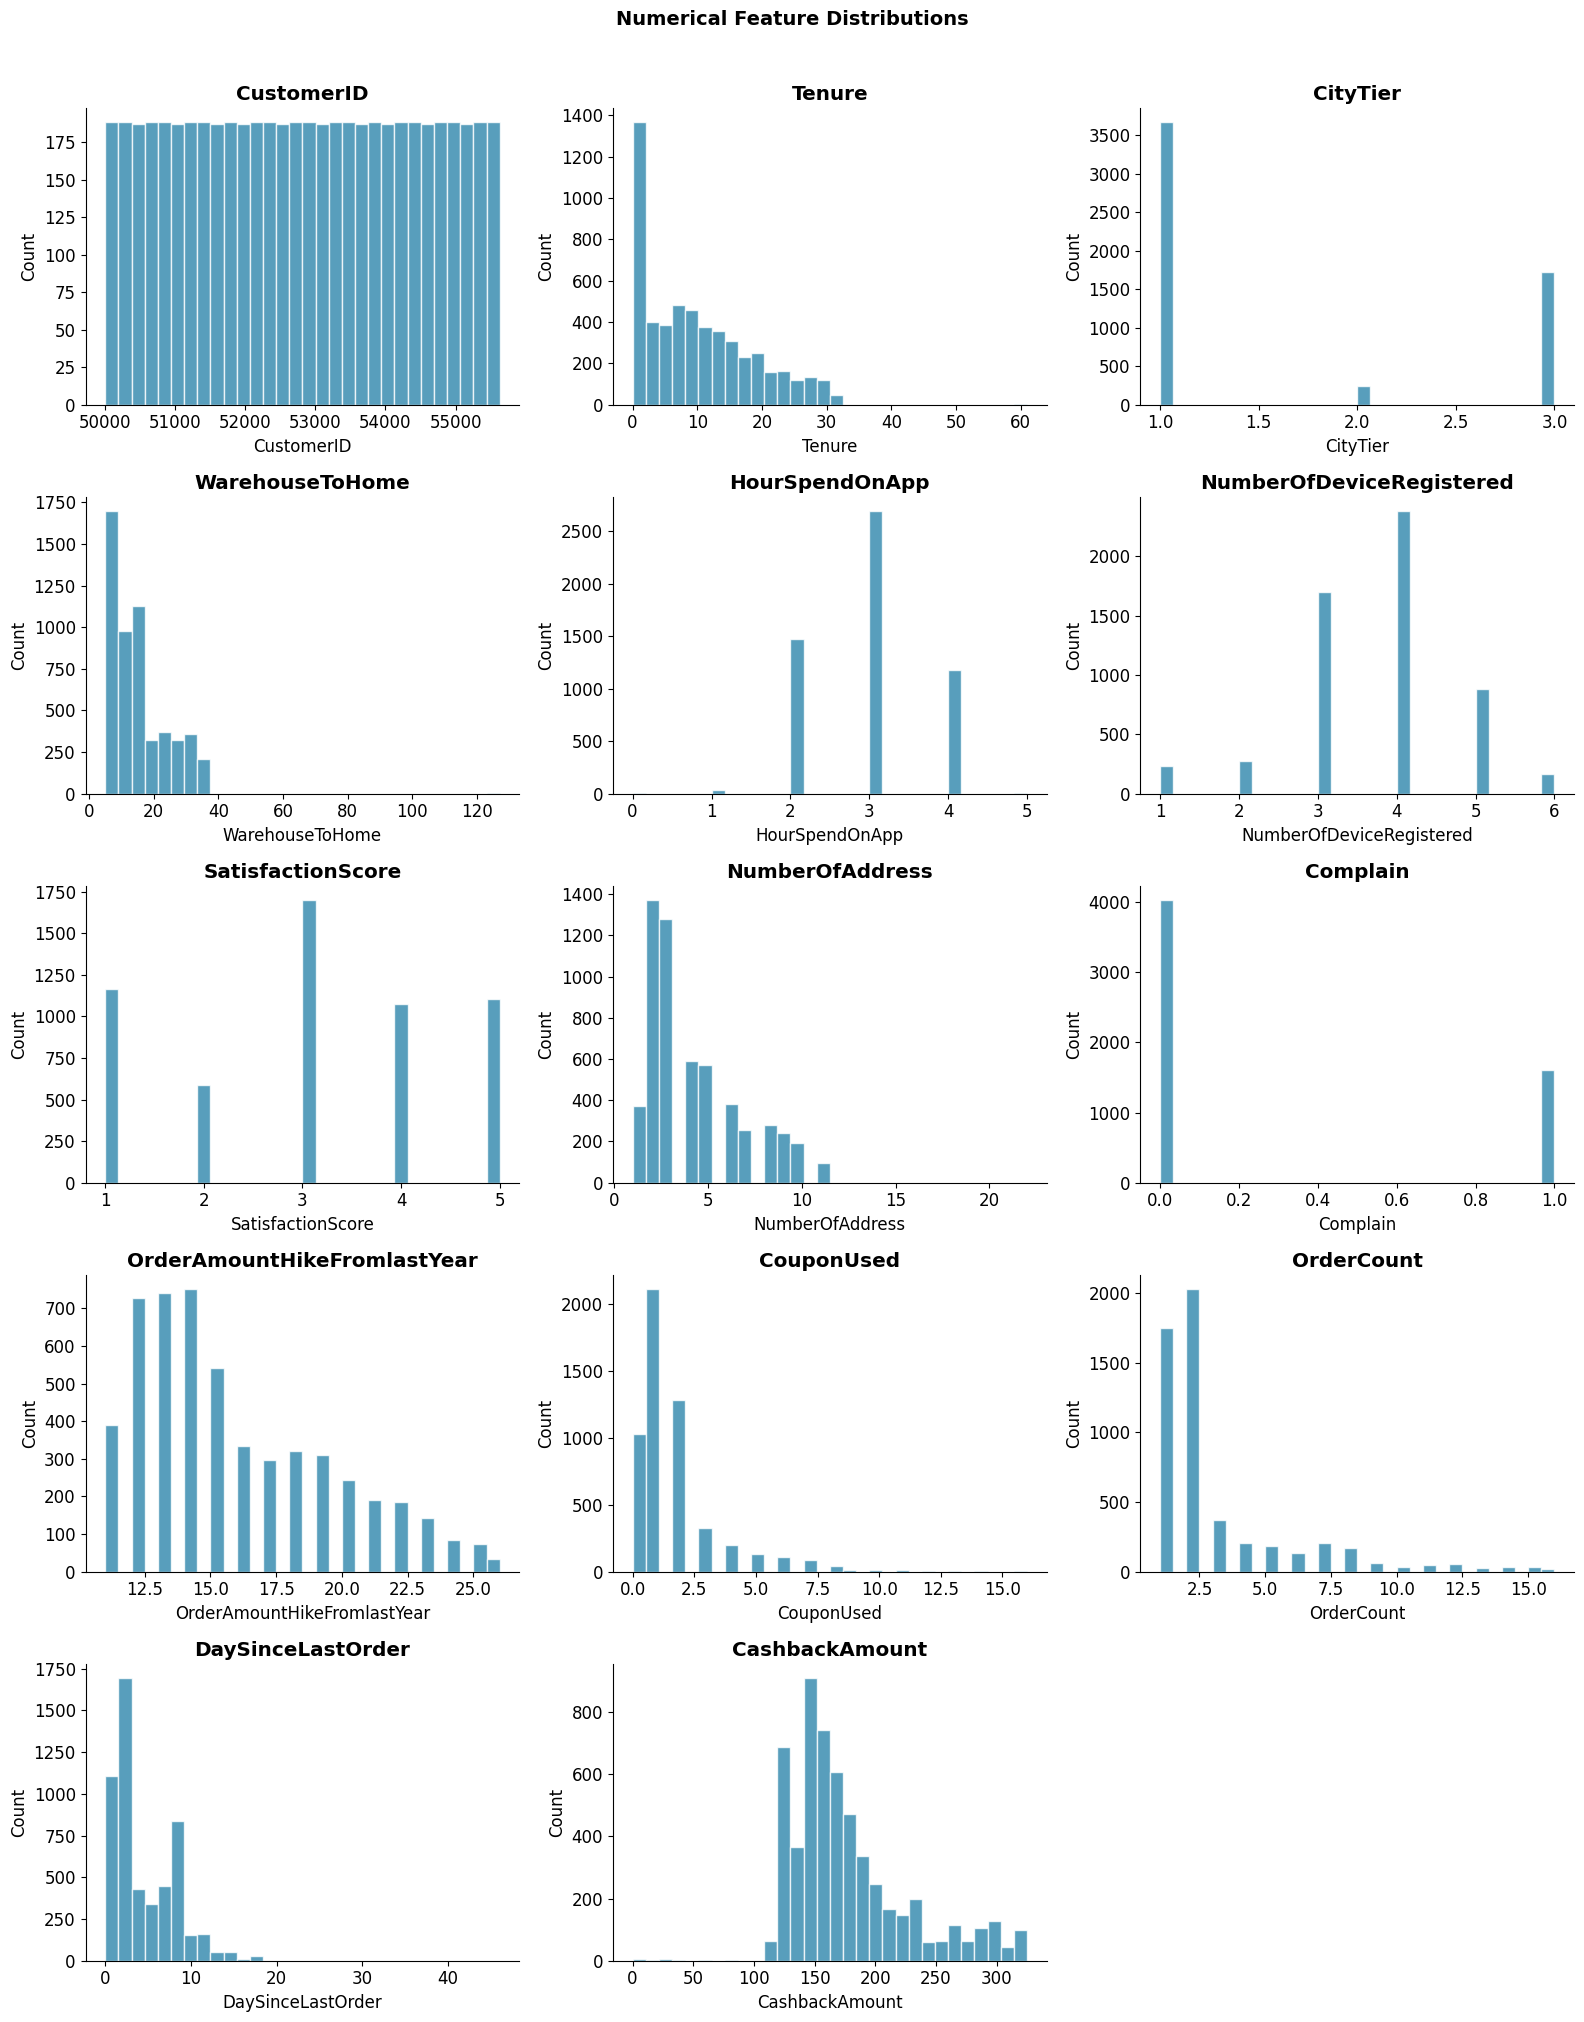

In [43]:
# Cell 8 — Numerical distributions
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'Churn']

print(f"Numerical columns: {numerical_cols}")

# Plot distributions
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#2E86AB',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

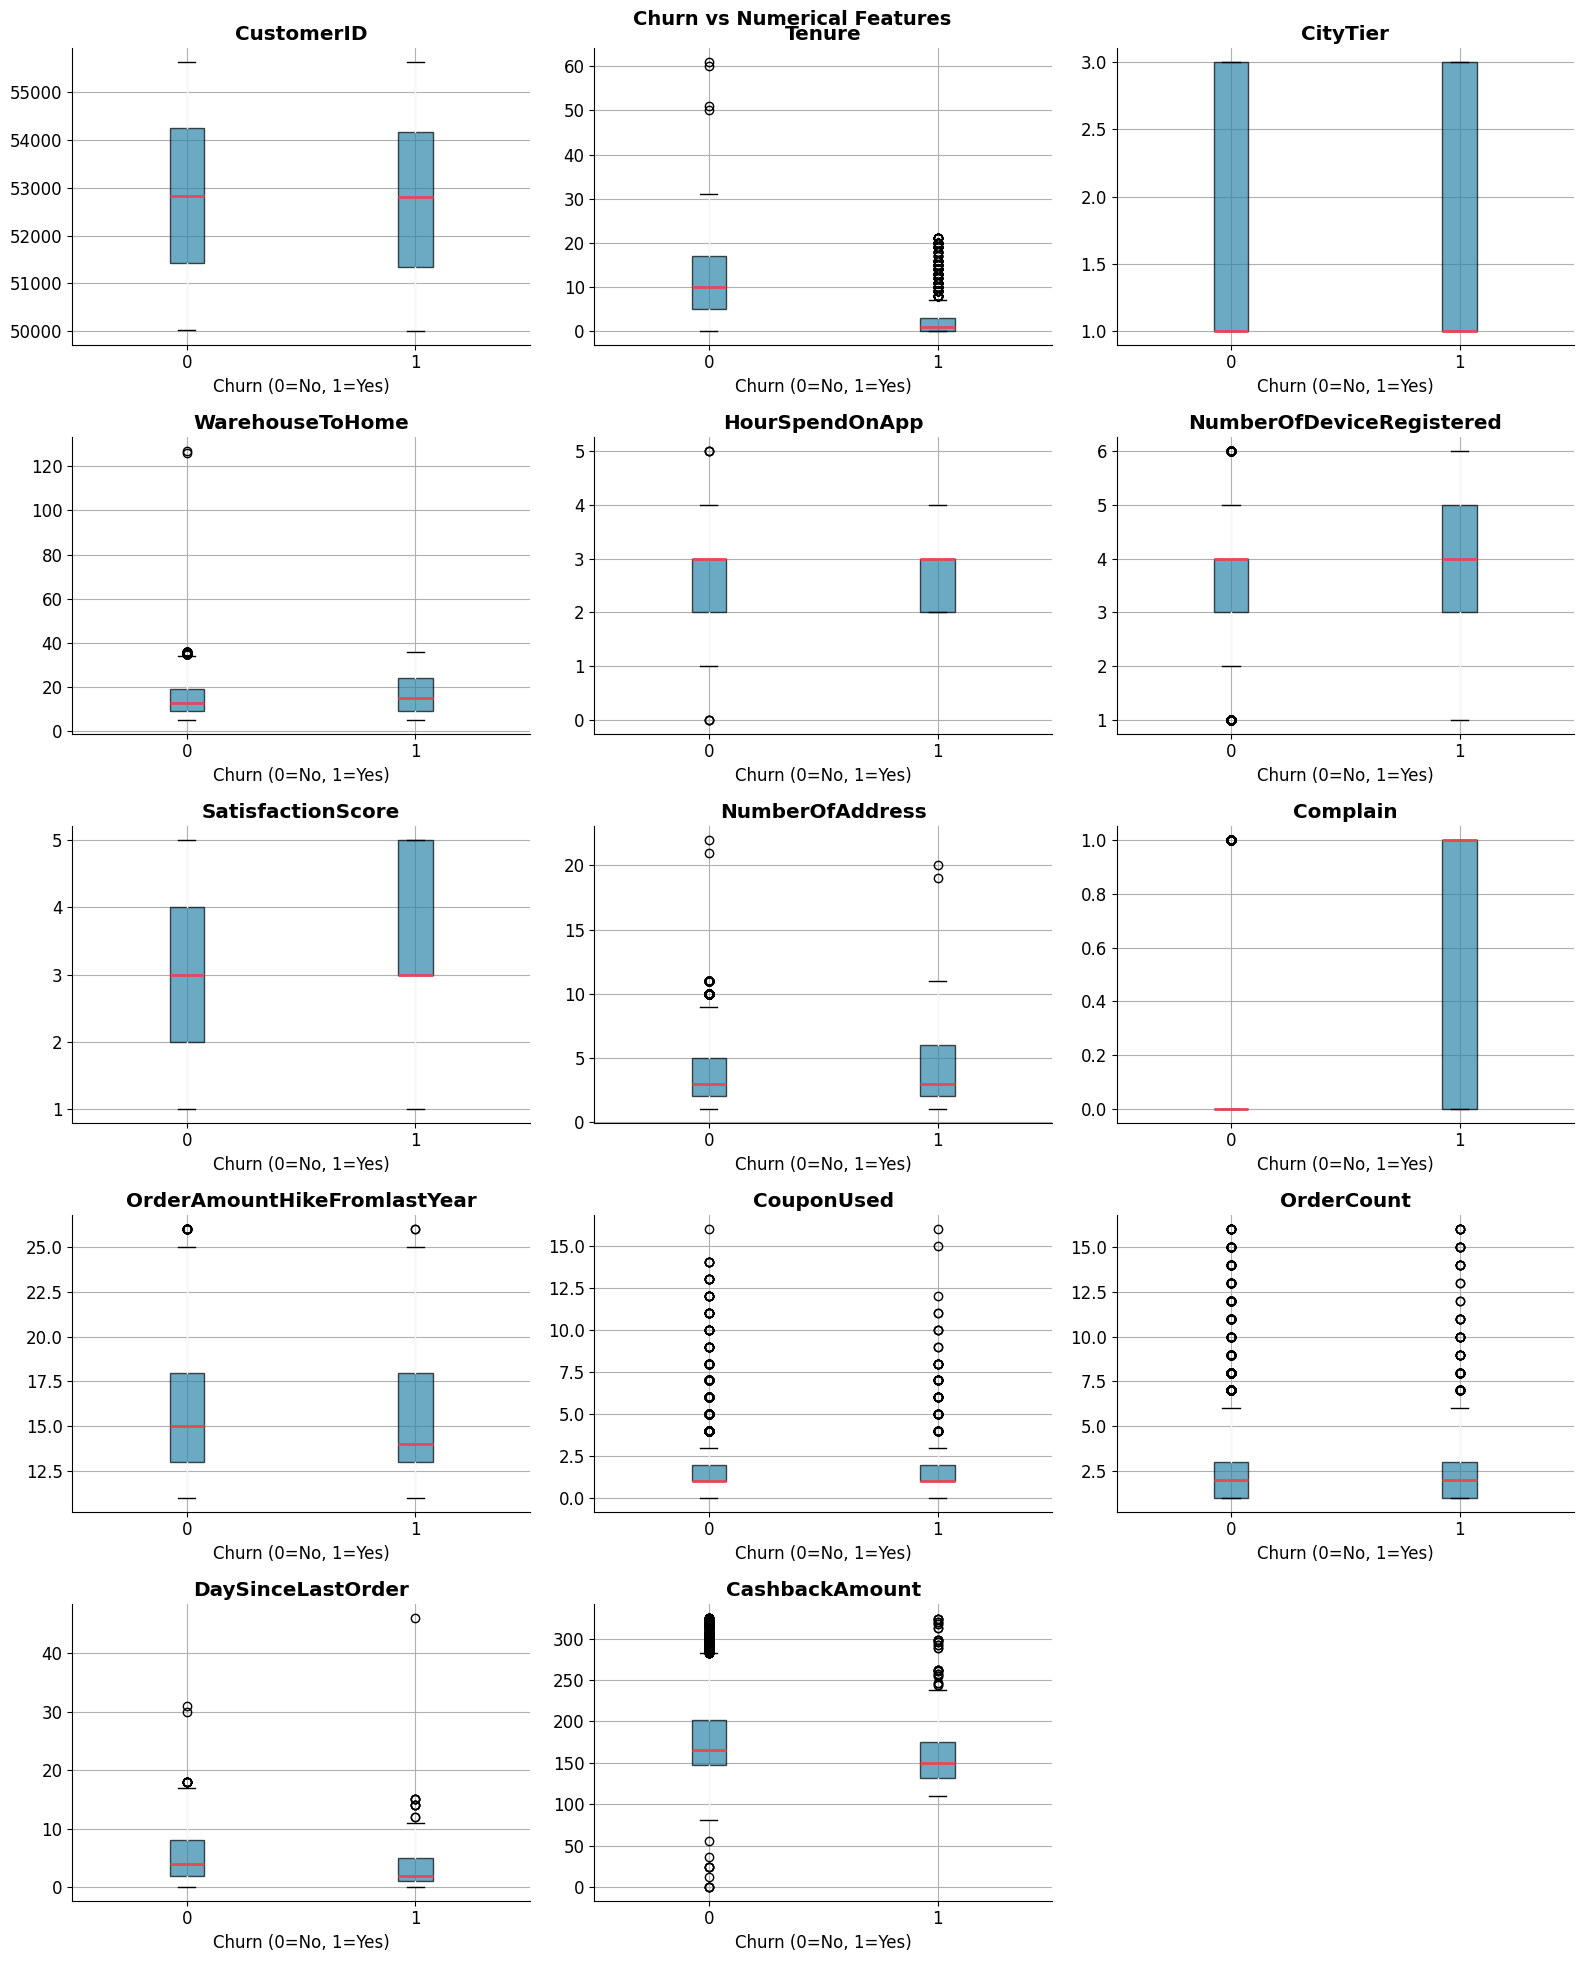

In [44]:
# Cell 9 — Churn vs numerical features (boxplots)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='Churn', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='#2E86AB', alpha=0.7),
               medianprops=dict(color='#E84855', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn vs Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_churn_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

Categorical columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


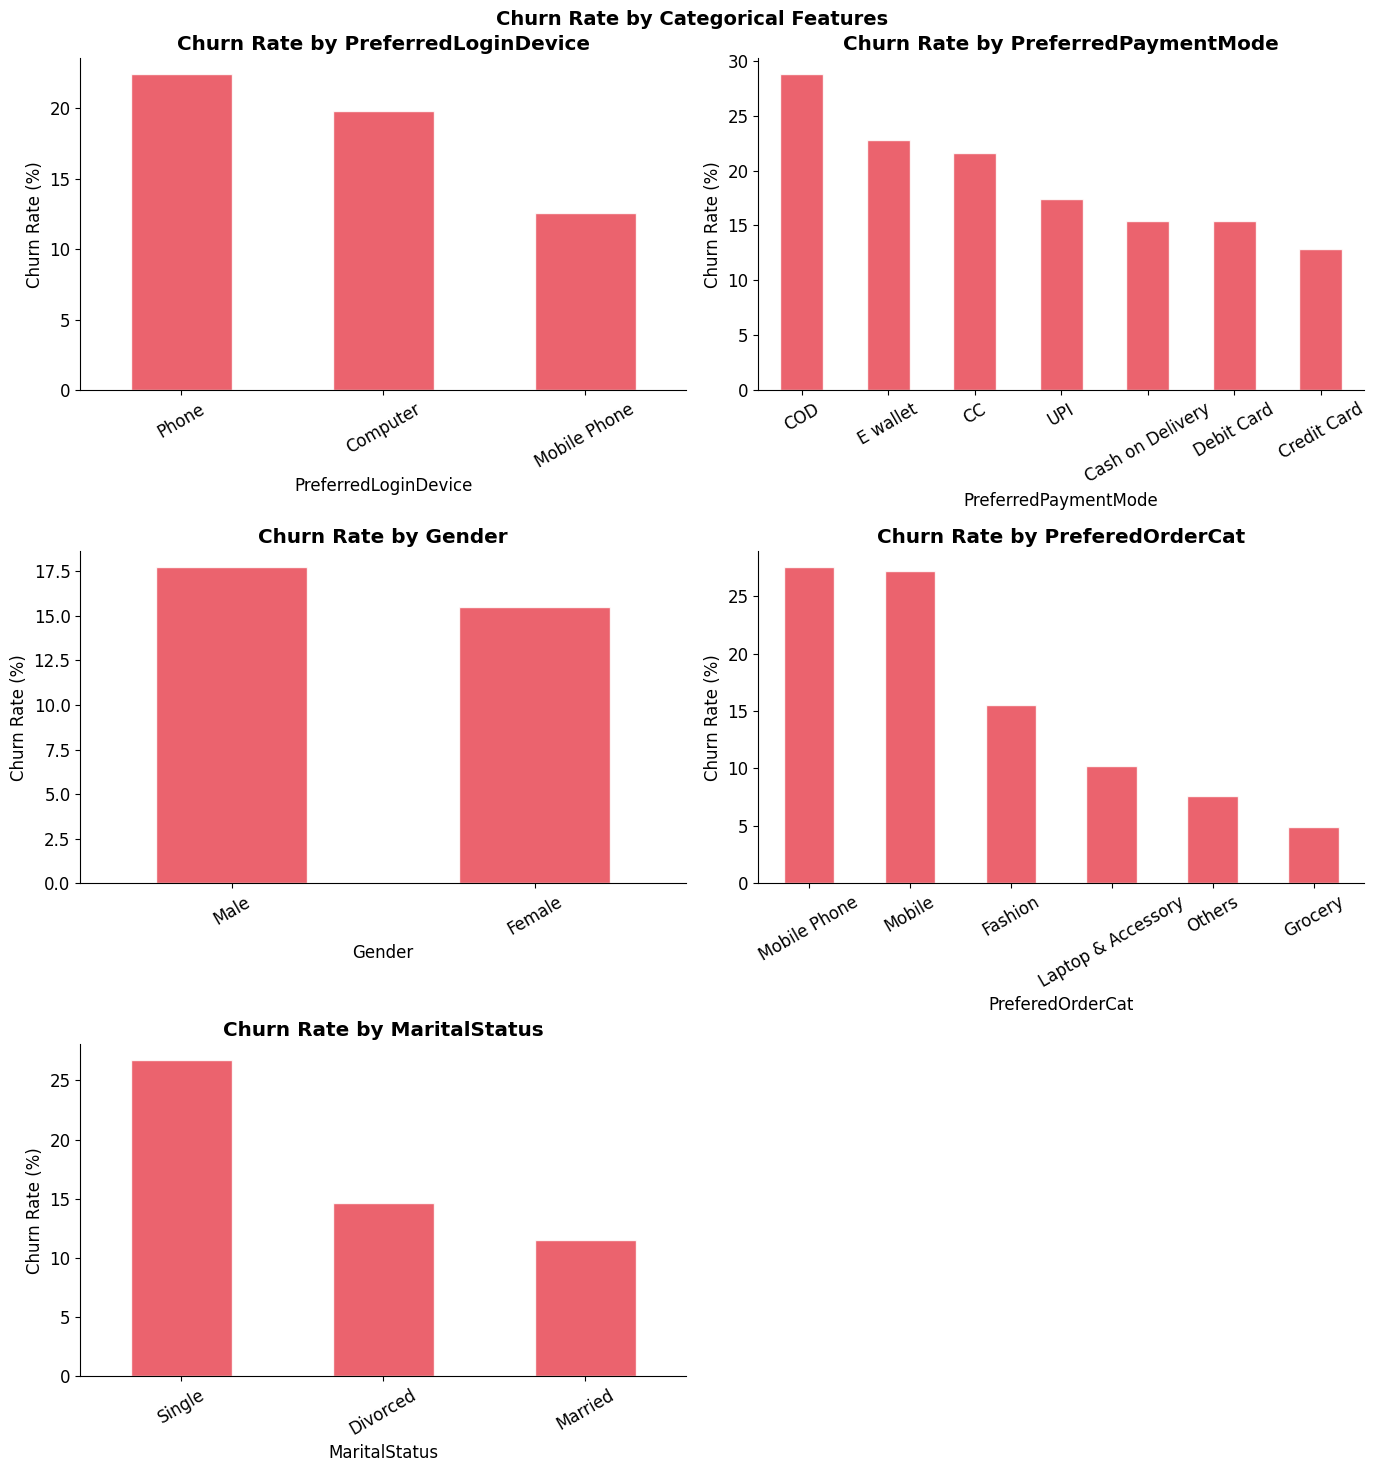

In [45]:
# Cell 10 — Categorical columns vs Churn
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

if len(categorical_cols) > 0:
    n_cat_cols = 2
    n_cat_rows = (len(categorical_cols) + n_cat_cols - 1) // n_cat_cols

    fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(14, n_cat_rows * 5))
    axes = axes.flatten() if n_cat_rows > 1 else [axes] if n_cat_cols == 1 else axes

    for i, col in enumerate(categorical_cols):
        churn_by_cat = df.groupby(col)['Churn'].mean() * 100
        churn_by_cat.sort_values(ascending=False).plot(
            kind='bar', ax=axes[i],
            color='#E84855', edgecolor='white', alpha=0.85
        )
        axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
        axes[i].set_ylabel('Churn Rate (%)')
        axes[i].set_xlabel(col)
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/05_categorical_churn.png', dpi=150, bbox_inches='tight')
    plt.show()

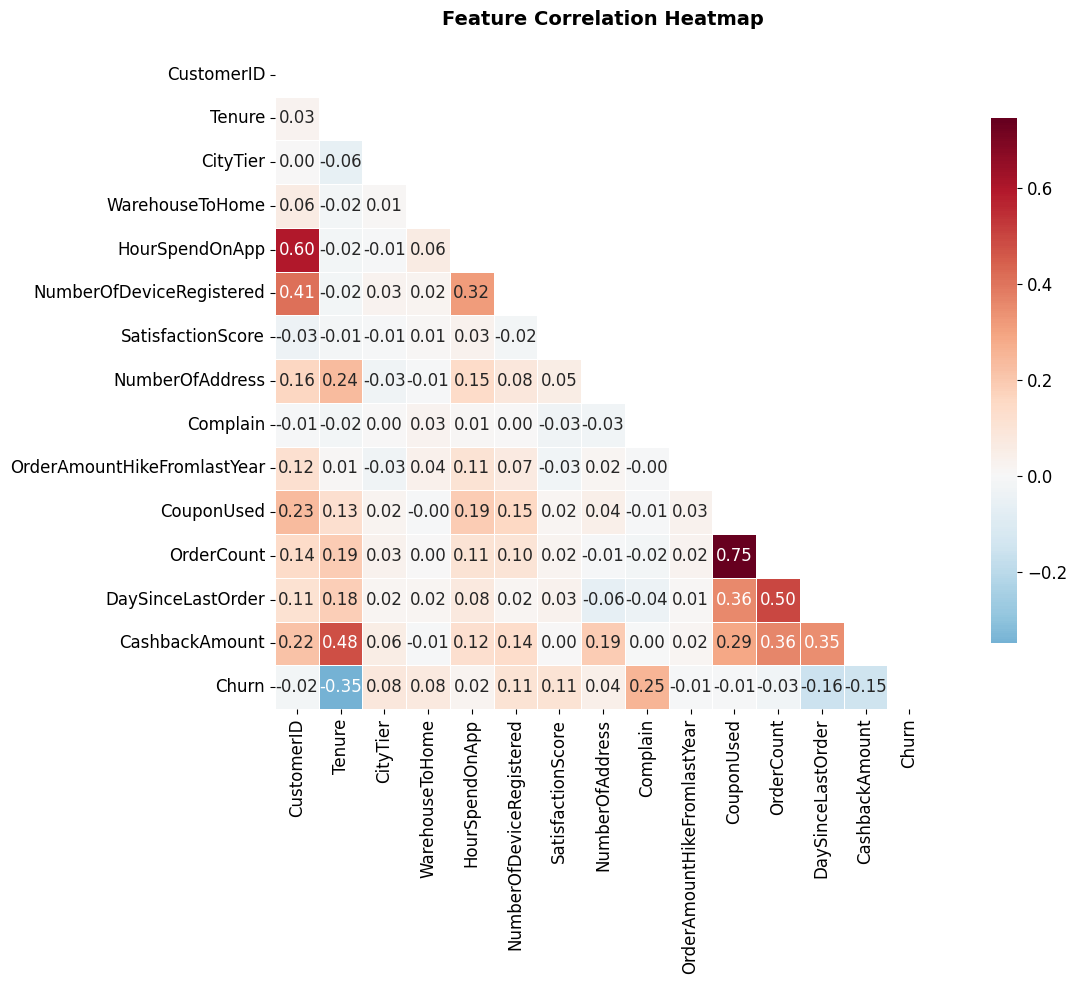


Top features correlated with Churn:
Complain                       0.250188
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
HourSpendOnApp                 0.018675
CouponUsed                    -0.008264
OrderAmountHikeFromlastYear   -0.010058
CustomerID                    -0.019083
OrderCount                    -0.028697
CashbackAmount                -0.154118
DaySinceLastOrder             -0.160757
Tenure                        -0.349408
Name: Churn, dtype: float64


In [46]:
# Cell 11 — Correlation heatmap
plt.figure(figsize=(14, 10))

corr_matrix = df[numerical_cols + ['Churn']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn
print("\nTop features correlated with Churn:")
print(corr_matrix['Churn'].drop('Churn').sort_values(ascending=False))

In [47]:
# Cell 12 — Save cleaned dataset info + EDA notes
summary = {
    'total_rows': df.shape[0],
    'total_columns': df.shape[1],
    'churn_rate_%': round(df['Churn'].mean() * 100, 2),
    'missing_columns': list(missing_df.index) if len(missing_df) > 0 else [],
    'numerical_features': numerical_cols,
    'categorical_features': categorical_cols
}

print("EDA SUMMARY")
print("=" * 50)
for k, v in summary.items():
    print(f"{k}: {v}")

# Save raw data reference copy info
print("\nDataset is ready for feature engineering (Day 3)")

EDA SUMMARY
total_rows: 5630
total_columns: 20
churn_rate_%: 16.84
missing_columns: ['DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'Tenure', 'OrderCount', 'CouponUsed', 'HourSpendOnApp', 'WarehouseToHome']
numerical_features: ['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
categorical_features: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Dataset is ready for feature engineering (Day 3)
